In [5]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [8]:
model = ChatGroq(model="openai/gpt-oss-120b")

In [16]:
model.invoke("why sky is blue").content

'The sky looks blue because of **Rayleigh scattering**—the way tiny molecules in Earth’s atmosphere bend (scatter) sunlight.\n\n1. **Sunlight is white, but it’s actually a mix of colors.**  \n   Each color corresponds to a different wavelength: violet and blue have short wavelengths, red and orange have long ones.\n\n2. **When sunlight enters the atmosphere, it collides with air molecules (nitrogen, oxygen, etc.).**  \n   These particles are much smaller than the wavelength of visible light, so they scatter the light in all directions. The amount of scattering is inversely proportional to the fourth power of the wavelength (∝\u202f1/λ⁴).  \n\n   - Short‑wavelength light (blue, violet) gets scattered **much more** than long‑wavelength light (red, orange).\n\n3. **Our eyes see the scattered light.**  \n   The sky is illuminated by the blue light that’s been redirected toward us from every part of the atmosphere. Although violet is scattered even more, our eyes are less sensitive to viole

In [9]:
# create a state

class LLMState(TypedDict):
    question: str
    answer: str

In [10]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [11]:
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

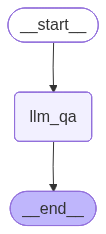

In [12]:
graph.compile()

In [13]:
# execute

intial_state = {'question': 'How far is moon from the earth?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])



The Moon is, on average, about **384 400 kilometers (≈238 900 miles)** away from Earth. Because its orbit is elliptical, the distance varies:

- **Perigee (closest approach):** ~363 300 km (≈225 600 mi)  
- **Apogee (farthest point):** ~405 500 km (≈251 900 mi)

So the typical distance you’ll hear quoted—≈384 400 km—represents the mean of those extremes.


In [14]:
model.invoke('How far is moon from the earth?').content

'The Moon’s distance from Earth isn’t a single fixed number because its orbit is slightly elliptical.  \n\n| Parameter | Approximate value |\n|-----------|-------------------|\n| **Average (mean) distance** | **384\u202f400\u202fkm** (≈\u202f238\u202f900\u202fmi) |\n| **Perigee (closest approach)** | ~363\u202f300\u202fkm (≈\u202f225\u202f700\u202fmi) |\n| **Apogee (farthest point)** | ~405\u202f500\u202fkm (≈\u202f251\u202f900\u202fmi) |\n\n**What this means**\n\n- **Average distance** (~384\u202f400\u202fkm) is the figure most textbooks and space agencies quote.  \n- When the Moon is at **perigee**, it appears about 14\u202f% larger in the sky and the Earth‑Moon system’s gravitational interaction is strongest.  \n- At **apogee**, the Moon looks smaller and the distance is roughly 11\u202f% greater than the average.\n\nThese values are measured from the centers of the two bodies. If you’re interested in the distance from the Earth’s surface to the Moon’s surface, subtract the Earth’s 